<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 155.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 142.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 160.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 157.6 MB/s eta 0:00:00


<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


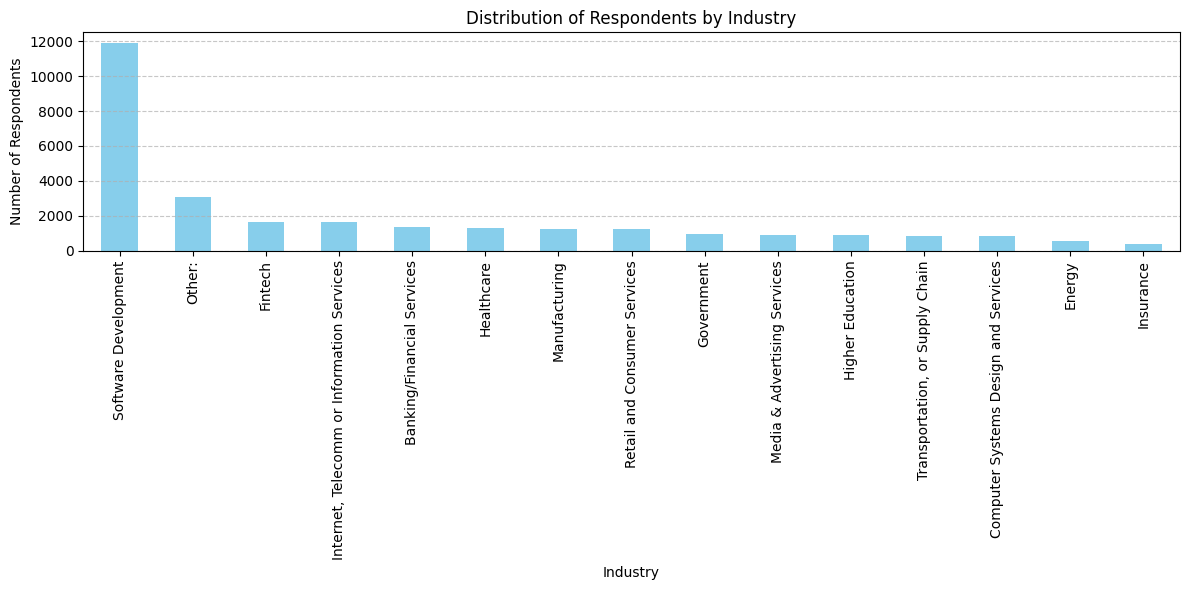

In [6]:

# Count the number of respondents per industry
industry_counts = df['Industry'].value_counts()

# Plot the bar chart
plt.figure(figsize=(12, 6))
industry_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Industry')
plt.ylabel('Number of Respondents')
plt.title('Distribution of Respondents by Industry')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


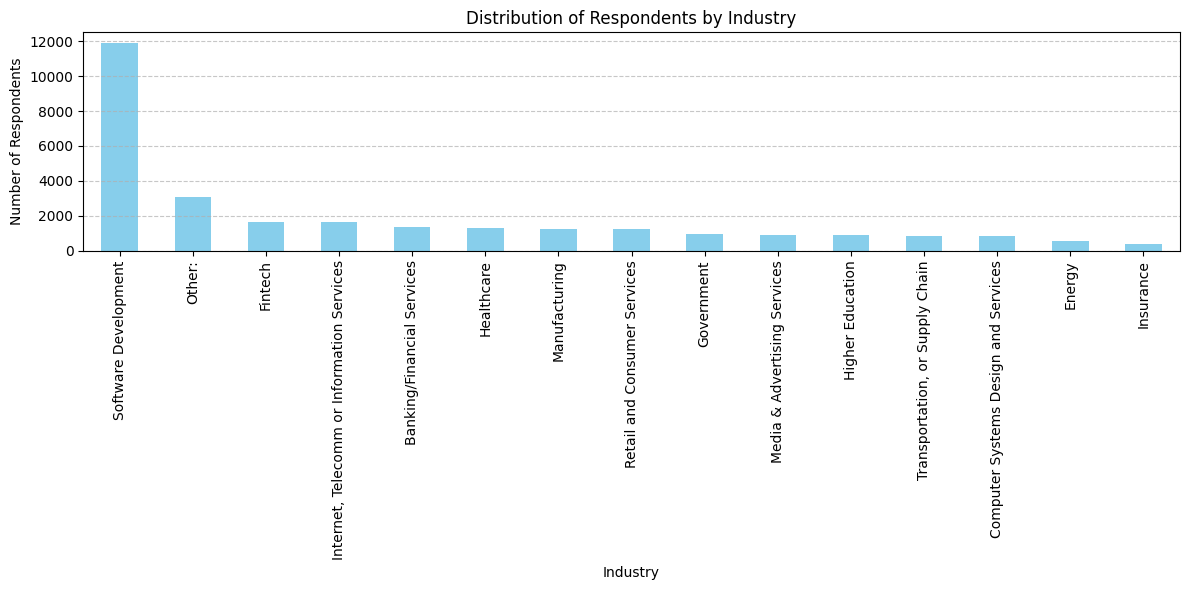

In [5]:
##Write your code here

# Group by 'Industry' and count the number of respondents
industry_counts = df.groupby('Industry').size().sort_values(ascending=False)

# Plot the bar chart
plt.figure(figsize=(12, 6))
industry_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Industry')
plt.ylabel('Number of Respondents')
plt.title('Distribution of Respondents by Industry')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [8]:
##Write your code here

# Ensure the column exists and clean the data
if 'ConvertedCompYearly' in df.columns:
    comp_data = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce').dropna()

    # Calculate statistics
    mean_val = comp_data.mean()
    median_val = comp_data.median()
    std_dev = comp_data.std()

    # Define threshold for outliers
    threshold = mean_val + 3 * std_dev
    outliers = comp_data[comp_data > threshold]

    # Display results
    print(f"Mean: {mean_val:.2f}")
    print(f"Median: {median_val:.2f}")
    print(f"Standard Deviation: {std_dev:.2f}")
    print(f"Outlier Threshold: {threshold:.2f}")
    print(f"Number of Outliers: {len(outliers)}")
    print("Outlier Values:")
    print(outliers)
else:
    print("The dataset does not contain a 'ConvertedCompYearly' column.")


Mean: 86155.29
Median: 65000.00
Standard Deviation: 186756.97
Outlier Threshold: 646426.21
Number of Outliers: 89
Outlier Values:
529       650000.0
828      1000000.0
1932      945000.0
2171      750000.0
2187     2000000.0
           ...    
38219    1000000.0
39643    1300000.0
40066     800000.0
40952     750000.0
41027     700000.0
Name: ConvertedCompYearly, Length: 89, dtype: float64


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Q1 (25th percentile): 32712.00
Q3 (75th percentile): 107971.50
IQR: 75259.50
Lower Bound: -80177.25
Upper Bound: 220860.75
Number of Outliers: 978
Outlier Values:
428      230000.0
456      300000.0
461      254425.0
529      650000.0
545      400000.0
           ...   
40952    750000.0
41000    235000.0
41001    260000.0
41027    700000.0
41187    222834.0
Name: ConvertedCompYearly, Length: 978, dtype: float64


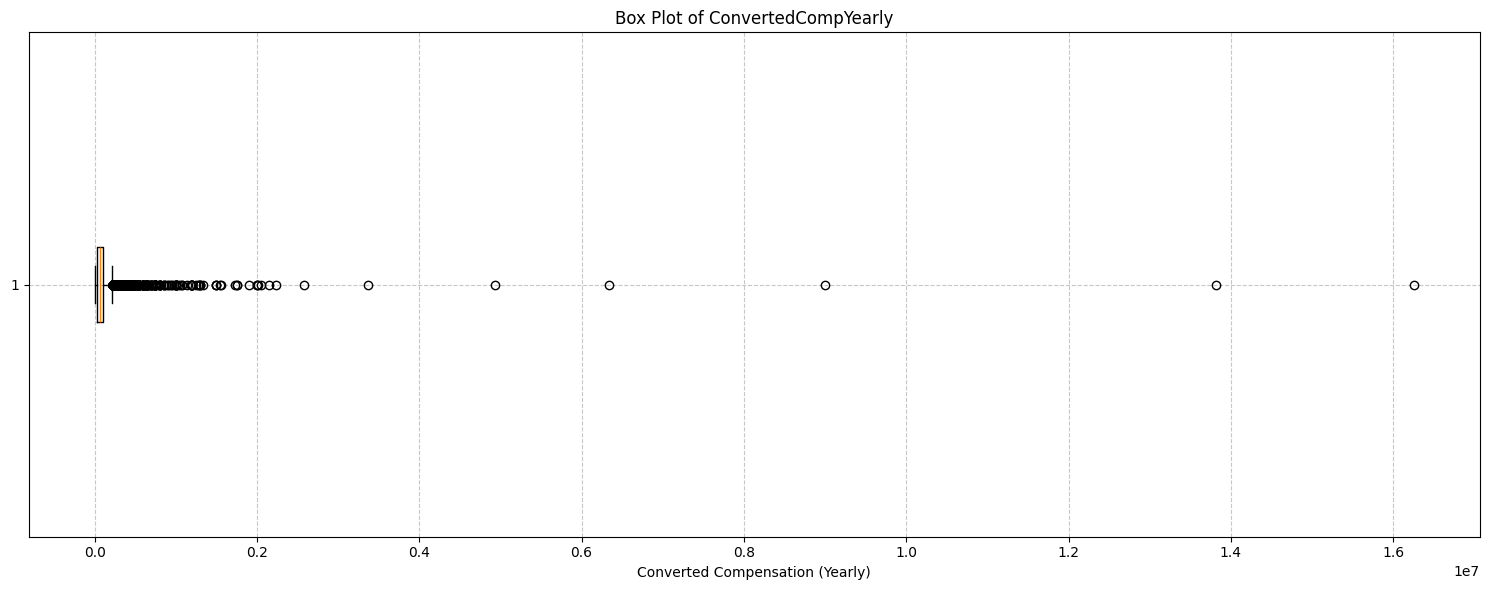

In [11]:

# Ensure the column exists and clean the data
if 'ConvertedCompYearly' in df.columns:
    # Convert to numeric and drop missing values
    comp_data = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce').dropna()

    # Calculate Q1 and Q3
    Q1 = comp_data.quantile(0.25)
    Q3 = comp_data.quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Determine bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = comp_data[(comp_data < lower_bound) | (comp_data > upper_bound)]

    # Print statistics
    print(f"Q1 (25th percentile): {Q1:.2f}")
    print(f"Q3 (75th percentile): {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Number of Outliers: {len(outliers)}")
    print("Outlier Values:")
    print(outliers)

    # Visualize with a box plot
    plt.figure(figsize=(15, 6))
    plt.boxplot(comp_data, vert=False)
    plt.title('Box Plot of ConvertedCompYearly')
    plt.xlabel('Converted Compensation (Yearly)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("The dataset does not contain a 'ConvertedCompYearly' column.")


<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [14]:
##Write your code here

# Ensure the column exists and clean the data
if 'ConvertedCompYearly' in df.columns:
    # Convert to numeric and drop missing values
    comp_data = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')

    # Calculate Q1 and Q3
    Q1 = comp_data.quantile(0.25)
    Q3 = comp_data.quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Determine bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers
    df_cleaned = df[(comp_data >= lower_bound) & (comp_data <= upper_bound)]

    # Save or use df_cleaned as needed
    print(f"Original dataset size: {len(df)}")
    print(f"Cleaned dataset size: {len(df_cleaned)}")
else:
    print("The dataset does not contain a 'ConvertedCompYearly' column.")
print("\n")
print(df_cleaned.info())


Original dataset size: 65437
Cleaned dataset size: 22457


<class 'pandas.core.frame.DataFrame'>
Index: 22457 entries, 72 to 41186
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 19.7+ MB
None


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [20]:
df_cleaned.dtypes

ResponseId               int64
MainBranch              object
Age                     object
Employment              object
RemoteWork              object
                        ...   
JobSatPoints_11        float64
SurveyLength            object
SurveyEase              object
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object

In [21]:
df_cleaned['Age'].value_counts()

Age
25-34 years old       10061
35-44 years old        5859
18-24 years old        3409
45-54 years old        2148
55-64 years old         782
65 years or older       127
Under 18 years old       63
Prefer not to say         8
Name: count, dtype: int64

In [22]:
##Write your code here

# Mapping age categories to numerical values (midpoints or representative values)
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': None  # or use a placeholder like -1
}

# Apply the mapping
df_cleaned['AgeNumeric'] = df_cleaned['Age'].map(age_map)

print(df_cleaned)


       ResponseId                                         MainBranch  \
72             73                     I am a developer by profession   
374           375  I am not primarily a developer, but I write co...   
379           380                     I am a developer by profession   
385           386                     I am a developer by profession   
389           390                     I am a developer by profession   
...           ...                                                ...   
41179       41180                     I am a developer by profession   
41180       41181                     I am a developer by profession   
41184       41185                     I am a developer by profession   
41185       41186                     I am a developer by profession   
41186       41187                     I am a developer by profession   

                   Age                                         Employment  \
72     18-24 years old  Employed, full-time;Student, full-

/tmp/ipykernel_301/354308313.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['AgeNumeric'] = df_cleaned['Age'].map(age_map)


Correlation matrix:
                     AgeNumeric  ConvertedCompYearly
AgeNumeric             1.000000             0.121512
ConvertedCompYearly    0.121512             1.000000


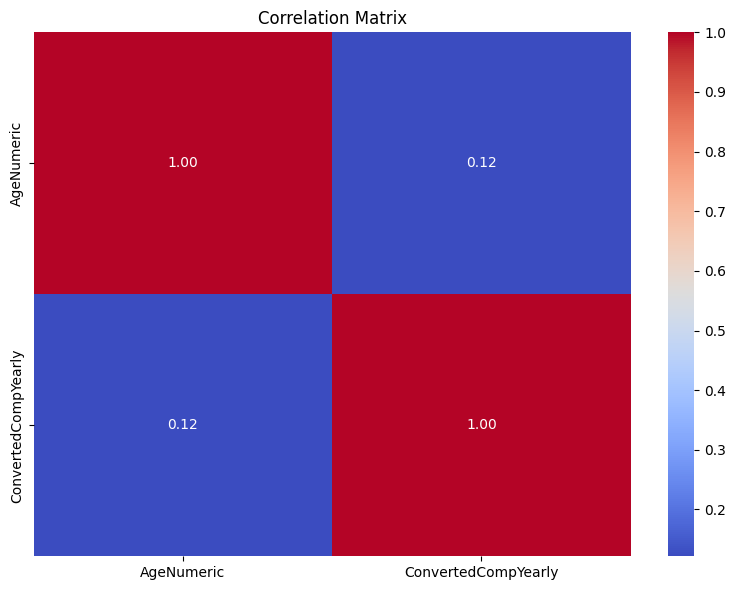

In [24]:

# Drop rows with missing values in relevant columns

df['AgeNumeric'] = df['Age'].map(age_map)

df_cleaned2 = df.dropna(subset=['AgeNumeric', 'ConvertedCompYearly'])

# Compute correlation matrix
correlation_matrix = df_cleaned2[['AgeNumeric', 'ConvertedCompYearly']].corr()

# Print correlation matrix
print("Correlation matrix:")
print(correlation_matrix)

# Visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
